In [5]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
print(torch.__version__)
print(torch.cuda.is_available())

Looking in indexes: https://download.pytorch.org/whl/cu126
2.10.0+cu126
True


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc
)

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head(5)
print(df.shape)
df = df.drop("id", axis=1)
print(df.shape)

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df['Heart Disease'] = encoder.fit_transform(df[['Heart Disease']])
df.head(5)

from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head(5)
print(X_train.shape, y_train.shape)

(630000, 15)
(630000, 14)
(504000, 13) (504000,)


In [8]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    return device

get_device()

Using device: cuda


device(type='cuda')

In [9]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size=16):
    
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, test_loader

In [10]:
class HeartDiseaseANN(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseANN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(16, 1)   
        )
        
    def forward(self, x):
        return self.model(x)


In [11]:
def plot_predictions(history, metrics):

    # ---- Loss Plot ----
    plt.figure()
    plt.plot(history["train_loss"])
    plt.plot(history["test_loss"])
    plt.title("Train vs Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Test"])
    plt.show()

    # ---- F1 Plot ----
    plt.figure()
    plt.plot(history["train_f1"])
    plt.plot(history["test_f1"])
    plt.title("Train vs Test F1 Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.legend(["Train", "Test"])
    plt.show()

    # ---- ROC Curve ----
    plt.figure()
    plt.plot(metrics["fpr"], metrics["tpr"])
    plt.plot([0,1], [0,1])
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # ---- Precision-Recall Curve ----
    plt.figure()
    plt.plot(metrics["recall_curve"], metrics["precision_curve"])
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()


In [12]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=10):

    model.to(device)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_f1": [],
        "test_f1": []
    }

    for epoch in range(epochs):

        # ---- Training ----
        model.train()
        running_loss = 0.0
        all_train_preds = []
        all_train_labels = []

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_train_preds.extend(preds.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_f1 = f1_score(all_train_labels, all_train_preds)

        # ---- Testing ----
        model.eval()
        test_loss = 0.0
        all_test_preds = []
        all_test_labels = []
        all_test_probs = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                all_test_probs.extend(probs.cpu().numpy())
                all_test_preds.extend(preds.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())

        test_loss /= len(test_loader)
        test_f1 = f1_score(all_test_labels, all_test_preds)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_f1"].append(train_f1)
        history["test_f1"].append(test_f1)

        if (epoch+1) % 2 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} "
                  f"| Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f}")

    return history


In [13]:
def evaluate_model(model, test_loader, device):

    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

    pr_auc = auc(recall_curve, precision_curve)

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "ROC-AUC": roc_auc_score(all_labels, all_probs),
        "PR-AUC": pr_auc,
        "Precision": precision_score(all_labels, all_preds),
        "Recall (Sensitivity)": recall_score(all_labels, all_preds),
        "F1-Score": f1_score(all_labels, all_preds),
        "fpr": fpr,
        "tpr": tpr,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve
    }

    return metrics


In [14]:
def main(X_train, y_train, X_test, y_test):

    device = get_device()

    train_loader, test_loader = create_dataloaders(
        X_train, y_train, X_test, y_test
    )

    input_dim = X_train.shape[1]
    linear_model = HeartDiseaseANN(input_dim)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(linear_model.parameters(), lr=0.001)

    history = train_model(
        linear_model, train_loader, test_loader,
        criterion, optimizer, device, epochs=10
    )

    metrics = evaluate_model(linear_model, test_loader, device)

    plot_predictions(history, metrics)

    return linear_model, metrics


Using device: cuda
Epoch [2/10] Train Loss: 0.3174 | Test Loss: 0.2935 | Train F1: 0.8586 | Test F1: 0.8604
Epoch [4/10] Train Loss: 0.3136 | Test Loss: 0.2908 | Train F1: 0.8600 | Test F1: 0.8667
Epoch [6/10] Train Loss: 0.3127 | Test Loss: 0.2892 | Train F1: 0.8602 | Test F1: 0.8664
Epoch [8/10] Train Loss: 0.3113 | Test Loss: 0.2936 | Train F1: 0.8607 | Test F1: 0.8652
Epoch [10/10] Train Loss: 0.3115 | Test Loss: 0.2884 | Train F1: 0.8604 | Test F1: 0.8645


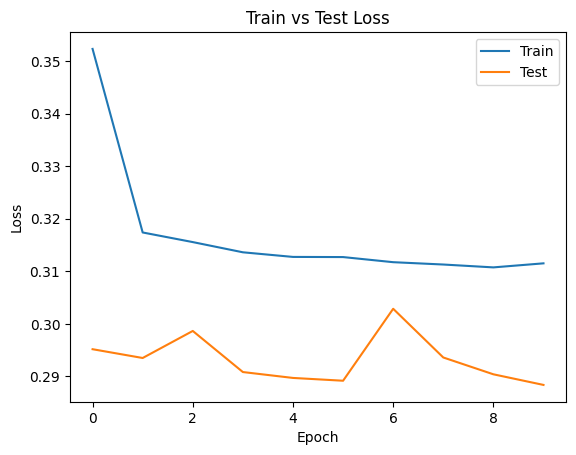

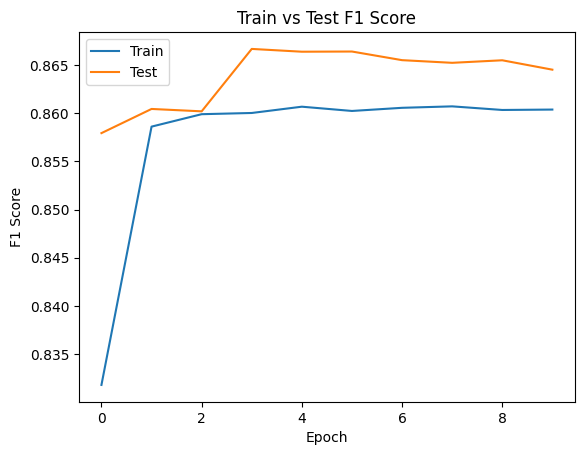

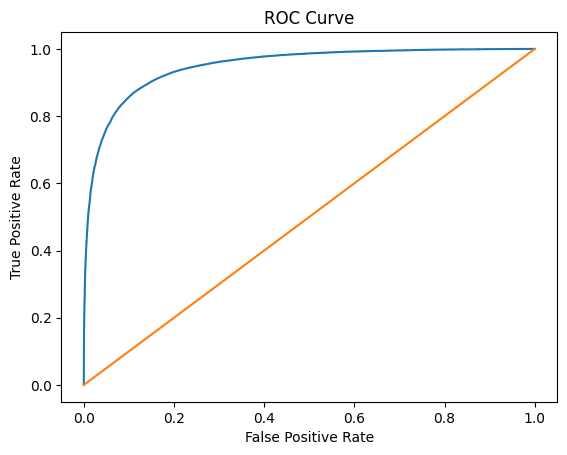

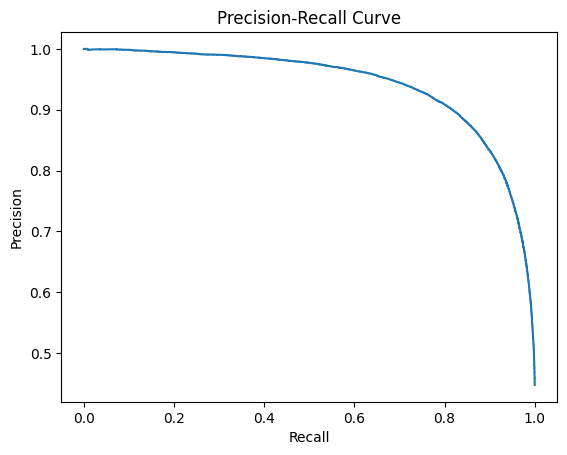

In [15]:
linear_model, metrics = main(X_train, y_train, X_test, y_test)

In [16]:
import os
model_path = os.path.join('models', 'heart_disease_ann.pth')
def save_model(model, path="heart_disease_ann.pth"):
    model_path = os.path.join('models', path)
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

def load_model(input_dim, path, device):
    model = HeartDiseaseANN(input_dim)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    print("Model loaded successfully!")
    return model


In [18]:
import pandas as pd
test_df = pd.read_csv('test.csv')
test_df.head(5)
test_ids = test_df["id"]   
X_test_final = test_df.drop("id", axis=1)
X_test_final = X_test_final[X_train.columns]
print(X_test_final.shape)

(270000, 13)


In [19]:
import pandas as pd

def save_predictions(probs, filename="ANN_submission.csv"):

    submission = pd.DataFrame({
        "id": test_ids,
        "Heart disease": probs.flatten()
    })

    submission.to_csv(filename, index=False)
    print(f"Predictions saved to {filename}")

In [22]:
save_model(linear_model)
device = get_device()
input_dim = X_test_final.shape[1]

model_path = os.path.join('models', 'heart_disease_ann.pth')
loaded_linear_model = load_model(input_dim, model_path, device)
test_dataset = TensorDataset(torch.tensor(X_test_final.values, dtype=torch.float32))

def predict_test_probabilities(model, test_loader, device):
	model.eval()
	all_probs = []
	all_preds = []

	with torch.no_grad():
		for inputs in test_loader:
			inputs = inputs[0].to(device)

			outputs = model(inputs)
			probs = torch.sigmoid(outputs)
			preds = (probs > 0.5).float()

			all_probs.extend(probs.cpu().numpy())
			all_preds.extend(preds.cpu().numpy())

	return np.array(all_probs), np.array(all_preds)

test_loader = DataLoader(test_dataset, batch_size=16)
probs, preds = predict_test_probabilities(loaded_linear_model, test_loader, device)
save_predictions(probs)

Model saved to models/heart_disease_ann.pth
Using device: cuda
Model loaded successfully!
Predictions saved to ANN_submission.csv


In [27]:
print(metrics)
## convert metrics to dataframe
ann_metrics_df = pd.DataFrame([metrics]).drop(columns=["fpr", "tpr", "precision_curve", "recall_curve"])
ann_metrics_df['Model'] = 'ANN'
ann_metrics_df.to_csv("ANN_metrics.csv", index=False)
ann_metrics_df.head()

{'Accuracy': 0.880436507936508, 'ROC-AUC': 0.949234379211185, 'PR-AUC': 0.9415983413408078, 'Precision': 0.8777414583371378, 'Recall (Sensitivity)': 0.8516904103763555, 'F1-Score': 0.8645197262516076, 'fpr': array([0.        , 0.        , 0.        , ..., 0.99311425, 0.99311425,
       1.        ], shape=(23373,)), 'tpr': array([0.00000000e+00, 1.77191863e-05, 1.82507619e-03, ...,
       9.99982281e-01, 1.00000000e+00, 1.00000000e+00], shape=(23373,)), 'precision_curve': array([0.44790476, 0.44790832, 0.44791187, ..., 1.        , 1.        ,
       1.        ], shape=(125207,)), 'recall_curve': array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       3.54383727e-05, 1.77191863e-05, 0.00000000e+00], shape=(125207,))}


,Accuracy,ROC-AUC,PR-AUC,Precision,Recall (Sensitivity),F1-Score,Model
0,0.880437,0.949234,0.941598,0.877741,0.85169,0.86452,ANN


In [30]:
model_comparison_df = pd.read_csv("model_comparison.csv")
final_model_comparison_df = pd.concat([model_comparison_df, ann_metrics_df], ignore_index=True)
final_model_comparison_df.to_csv("final_model_comparison.csv", index=False)
final_model_comparison_df.sort_values(by="ROC-AUC", ascending=False).head(10)

,Model,Accuracy,ROC-AUC,PR-AUC,Precision,Recall (Sensitivity),F1-Score
3,XGBoost (Tuned),0.887000,0.955157,0.948310,0.866340,0.884117,0.875138
4,LightGBM,0.886468,0.954213,0.947363,0.872425,0.874389,0.873406
2,XGBoost,0.885389,0.954187,0.947343,0.863448,0.883904,0.873556
1,Random Forest,0.884532,0.952123,0.944658,0.869263,0.873591,0.871422
5,ANN,0.880437,0.949234,0.941598,0.877741,0.851690,0.864520
0,Decision Tree,0.880802,0.822730,0.847668,0.872462,0.859522,0.865944
